ex 4

In [ ]:
#ex4
import numpy as np

def methode_rebroussement(x, f, d, alpha, beta, grad_f):
    t=1
    grad_fx = grad_f(x)
    while f(x+t*d) > f(x) + alpha * t * np.dot(grad_fx,d):
        t = beta * t
    return t

In [ ]:
#ex4
import numpy as np

def f(w, Sigma, mu, llambda):
    return 0.5 * np.dot(w.T, np.dot(Sigma, w)) - llambda * np.dot(mu.T, w)

def grad_f(w, Sigma, mu, llambda):
    return np.dot(Sigma, w) - llambda * mu

def methode_rebroussment_1(w, Sigma, mu, llambda, d, f, grad_f, alpha=1/3, beta=1/2):
    t = 1
    fw = f(w, Sigma, mu, llambda)
    grad_fw = grad_f(w, Sigma, mu, llambda)
    while f(w + t*d, Sigma, mu, llambda) > fw + alpha * t * np.dot(grad_fw, d):
        t = t*beta
    return t

def par_w(w):
    w = np.maximum(w,0) #w > 0
    s = w.sum()
    return w/s #somme des w = 1

def opti_port(Sigma, mu, llambda, nb_it):
    n = len(mu) #n actifs dans le portefeuille
    w = np.ones(n)/n
    for _ in range(nb_it):
        g = grad_f(w, Sigma, mu, llambda)
        d = -g
        t = methode_rebroussment_1(w, Sigma, mu, llambda, d, f, grad_f, alpha=1/3, beta=1/2)
        w = w +t*d
        w = par_w(w)
    return w
#minimiser le risque en maximisant le rendement

In [ ]:
Sigma = np.array([[0.1, 0.02, 0.01],
                  [0.02, 0.08, 0.03],
                  [0.01, 0.03, 0.05]])

mu = np.array([0.12, 0.10, 0.07])

llambda = 2.0 

w_opt = opti_port(Sigma, mu, llambda, nb_it=100)
print("Poids optimaux :", w_opt)
print("Somme des poids :", w_opt.sum())


Poids optimaux : [0.41208013 0.34150948 0.24641038]
Somme des poids : 0.9999999999999999


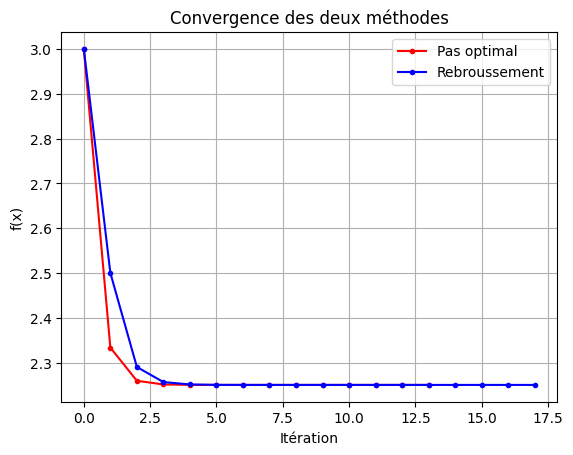

Gradient pas optimal x* = [-0.99999937  0.50000031] f* = 2.250000000000295
Gradient rebroussement x* = [-1.          0.50000021] f* = 2.250000000000046


In [ ]:
#ex 5
import numpy as np
import matplotlib.pyplot as plt

#Fonction quadratique
def f_quad(x, A, b, c):
    return 0.5 * np.dot(x.T, np.dot(A, x)) - np.dot(b.T, x) + c

def gradf_quad(x, A, b):
    return np.dot(A, x) - b

#Descente de gradient pas optimal
def gradient_optimal(x0, eps, A, b, c, max_iter=1000):
    x = np.array(x0, dtype=float)
    X, FX = [x.copy()], [f_quad(x, A, b, c)]
    for _ in range(max_iter):
        g = gradf_quad(x, A, b)
        if np.linalg.norm(g) < eps:
            break
        t = np.dot(g, g) / np.dot(g, np.dot(A, g))
        x = x - t * g
        X.append(x.copy())
        FX.append(f_quad(x, A, b, c))
    return np.array(X), np.array(FX)

#Descente de gradient avec rebroussement 
def backtracking(x, d, f, gradf, A, b, c, alpha=0.1, beta=0.7):
    t = 1.0
    fx = f(x, A, b, c)
    grad_fx = gradf(x, A, b)
    while f(x - t*d, A, b, c) > fx - alpha * t * np.dot(grad_fx, d):
        t *= beta
    return t

def gradient_backtracking(x0, eps, f, gradf, A, b, c, alpha=0.1, beta=0.7, max_iter=1000):
    x = np.array(x0, dtype=float)
    X, FX = [x.copy()], [f(x, A, b, c)]
    for _ in range(max_iter):
        g = gradf(x, A, b)
        if np.linalg.norm(g) < eps:
            break
        d = g
        t = backtracking(x, d, f, gradf, A, b, c, alpha, beta)
        x = x - t * d
        X.append(x.copy())
        FX.append(f(x, A, b, c))
    return np.array(X), np.array(FX)

# Exemple portefeuille 2 actifs 
gamma = 2
A = np.array([[1,0],[0,gamma]])
b = np.array([-1,1])
c = 3
x0 = [0,0]

# Gradient pas optimal
X_opt, FX_opt = gradient_optimal(x0, 1e-6, A, b, c)

# Gradient rebroussement
X_back, FX_back = gradient_backtracking(x0, 1e-6, f_quad, gradf_quad, A, b, c)

# Affichage convergence 
plt.plot(FX_opt, 'r.-', label='Pas optimal')
plt.plot(FX_back, 'b.-', label='Rebroussement')
plt.xlabel("Itération")
plt.ylabel("f(x)")
plt.title("Convergence des deux méthodes")
plt.legend()
plt.grid(True)
plt.show()


print("Gradient pas optimal x* =", X_opt[-1], "f* =", FX_opt[-1])
print("Gradient rebroussement x* =", X_back[-1], "f* =", FX_back[-1])


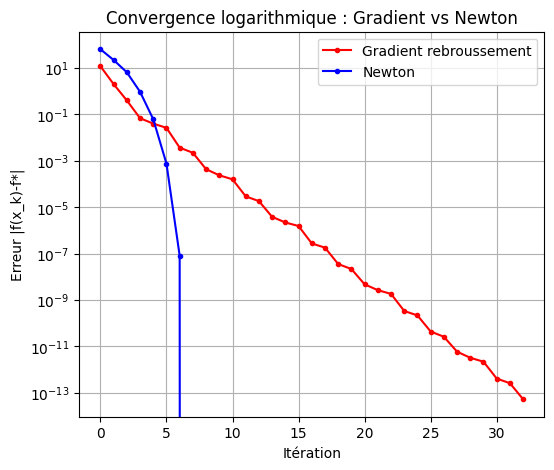

In [ ]:
#ex7
import numpy as np
import matplotlib.pyplot as plt


def fonction_exponentielle(x):
    return np.exp(x[0]+3*x[1]-0.1) + np.exp(x[0]-3*x[1]-0.1) + np.exp(-x[0]-0.1)

def gradient_fonction(x):
    return np.array([
        np.exp(x[0]+3*x[1]-0.1) + np.exp(x[0]-3*x[1]-0.1) - np.exp(-x[0]-0.1),
        3*np.exp(x[0]+3*x[1]-0.1) - 3*np.exp(x[0]-3*x[1]-0.1)
    ])

def hessienne_fonction(x):
    e1 = np.exp(x[0]+3*x[1]-0.1)
    e2 = np.exp(x[0]-3*x[1]-0.1)
    e3 = np.exp(-x[0]-0.1)
    return np.array([
        [e1 + e2 + e3, 3*e1 - 3*e2],
        [3*e1 - 3*e2, 9*e1 + 9*e2]
    ])

def descente_gradient_rebroussement(x0, eps, alpha, beta, f, gradf):
    Xk = []
    x = x0.copy()
    for _ in range(100):
        g = gradf(x)
        if np.linalg.norm(g) < eps:
            break
        d = -g
        t = 1
        while f(x + t*d) > f(x) + alpha*t*(g@d):
            t *= beta
        x = x + t*d
        Xk.append(x.copy())
    return np.array(Xk)

def descente_newton(x0, eps, f, gradf, hessf):
    Xk = []
    x = x0.copy()
    for _ in range(100):
        g = gradf(x)
        H = hessf(x)
        if np.linalg.norm(g) < eps:
            break
        d = -np.linalg.solve(H, g)
        x = x + d
        Xk.append(x.copy())
    return np.array(Xk)

x0 = np.array([-5.0, 3.0])
X_gradient = descente_gradient_rebroussement(x0, 1e-6, 0.1, 0.7, fonction_exponentielle, gradient_fonction)
X_newton = descente_newton(x0, 1e-6, fonction_exponentielle, gradient_fonction, hessienne_fonction)

# Calcul des erreurs f(x_k) - f* pour convergence logarithmique
f_star = fonction_exponentielle(X_newton[-1])  # on prend le minimum Newton comme référence
erreur_gradient = [fonction_exponentielle(x) - f_star for x in X_gradient]
erreur_newton = [fonction_exponentielle(x) - f_star for x in X_newton]

plt.figure(figsize=(6,5))
plt.semilogy(erreur_gradient, 'r.-', label='Gradient rebroussement')
plt.semilogy(erreur_newton, 'b.-', label='Newton')
plt.xlabel("Itération")
plt.ylabel("Erreur |f(x_k)-f*|")
plt.title("Convergence logarithmique : Gradient vs Newton")
plt.legend()
plt.grid(True, which='both')
plt.show()





Régression classique : a = 0.512727272727272 , b = -0.5999999999999961
Régression b>=0 : a = 0.42701298701298696 , b = 0


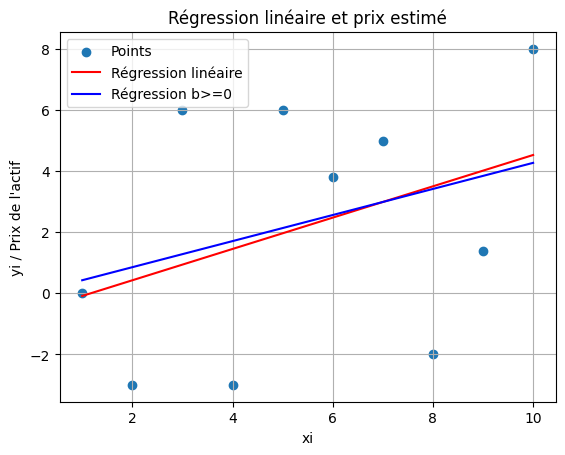

Prix estimé pour xi=11 :
 - Régression classique : 5.0399999999999965
 - Régression b>=0 : 4.697142857142857


In [ ]:
#ex1 td6
import numpy as np
import matplotlib.pyplot as plt


def regression_lin(x, y):
    """Régression linéaire classique"""
    Sx = np.sum(x)
    Sy = np.sum(y)
    Sx2 = np.sum(x**2)
    Sxy = np.sum(x*y)
    n = len(x)
    
    A = np.array([[Sx2, Sx],
                  [Sx, n]])
    v = 2 * np.array([Sxy, Sy])
    a,b = np.linalg.solve(A, v/2)
    return a,b

def regression_lin_bpos(x, y):
    """Régression linéaire avec b >= 0"""
    a,b = regression_lin(x,y)
    if b >= 0:
        return a,b
    else:
        a = np.sum(x*y)/np.sum(x**2)
        b = 0
        return a,b


xi = np.array([1,2,3,4,5,6,7,8,9,10])
yi = np.array([0,-3,6,-3,6,3.8,5,-2,1.4,8])


a1,b1 = regression_lin(xi, yi)
a2,b2 = regression_lin_bpos(xi, yi)

print("Régression classique : a =", a1, ", b =", b1)
print("Régression b>=0 : a =", a2, ", b =", b2)


plt.scatter(xi, yi, label="Points")
plt.plot(xi, a1*xi+b1, 'r', label="Régression linéaire")
plt.plot(xi, a2*xi+b2, 'b', label="Régression b>=0")
plt.xlabel("xi")
plt.ylabel("yi / Prix de l'actif")
plt.title("Régression linéaire et prix estimé")
plt.legend()
plt.grid(True)
plt.show()


def prix_actif(x, a, b):
    """Calcule le prix estimé d'un actif pour un xi donné"""
    return a*x + b

x_test = 11  # Exemple : on veut estimer le prix pour xi=11
prix_classique = prix_actif(x_test, a1, b1)
prix_bpos = prix_actif(x_test, a2, b2)

print(f"Prix estimé pour xi={x_test} :")
print(" - Régression classique :", prix_classique)
print(" - Régression b>=0 :", prix_bpos)


Poids estimés par Huber : [ 1.55733158 -2.0725774   0.49274472]
Poids réels : [ 1.5 -2.   0.5]


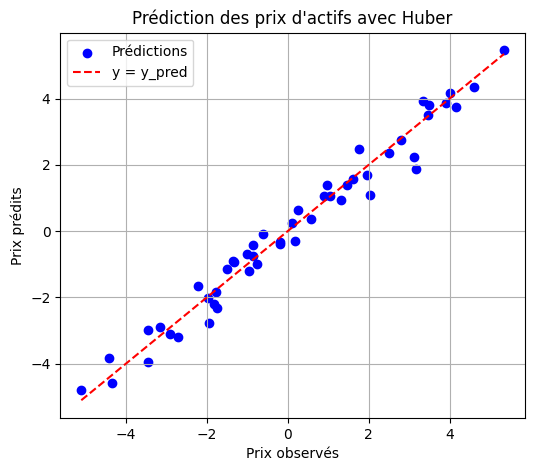

In [ ]:
#ex1 td7
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)
n, d = 50, 3  # nombre d'observations et de facteurs
X = np.random.randn(n, d)  # facteurs simulés
w_true = np.array([1.5, -2.0, 0.5])  # "vraie" sensibilité des facteurs
y = X @ w_true + np.random.randn(n) * 0.5  # prix simulés avec bruit


def huber_loss(t):
    """Perte de Huber"""
    return np.where(np.abs(t) < 1, 0.5 * t**2, np.abs(t) - 0.5)

def huber_grad(t):
    """Gradient de la perte de Huber"""
    return np.where(np.abs(t) < 1, t, np.sign(t))


alpha = 0.1  # pas de descente
w = np.zeros(d)  # initialisation des coefficients

for k in range(200):  # nombre d'itérations
    residuals = X @ w - y
    grad = np.mean(huber_grad(residuals)[:, None] * X, axis=0)
    w -= alpha * grad

print("Poids estimés par Huber :", w)
print("Poids réels :", w_true)


y_pred = X @ w
plt.figure(figsize=(6,5))
plt.scatter(y, y_pred, color='blue', label='Prédictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='y = y_pred')
plt.xlabel("Prix observés")
plt.ylabel("Prix prédits")
plt.title("Prédiction des prix d'actifs avec Huber")
plt.grid(True)
plt.legend()
plt.show()
